In [1]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
file_path = 'data/sentiment_data_cleaned.csv'  # Remplace par le chemin réel
data = pd.read_csv(file_path)

In [2]:
data.head()  # Statistiques descriptives pour les colonnes numériques

,TWEET,STOCK,DATE,CLEANED_TWEET,SENTIMENT
0,@FAME95FM1 Jamaicans make money with @Payoneer...,PAYPAL,2017-01-31,FAMEFM Jamaicans make money with Payoneer PayP...,0.0000
1,@CBSi Jamaicans make money with @Payoneer @Pay...,PAYPAL,2017-01-31,CBSi Jamaicans make money with Payoneer PayPal...,0.0000
2,@Hitz92fm Jamaicans make money with @Payoneer ...,PAYPAL,2017-01-31,Hitzfm Jamaicans make money with Payoneer PayP...,0.0000
3,"RT @nikitakhara: Thank you, @Starbucks CEO for...",STARBUCKS,2017-01-31,RT nikitakhara Thank you Starbucks CEO for com...,0.6908
4,@gawker Jamaicans make money with @Payoneer @P...,PAYPAL,2017-01-31,gawker Jamaicans make money with Payoneer PayP...,0.0000


In [3]:
# Description de chaque colonne
description = {
    "TWEET": {
        "type": "texte",
        "example": data['TWEET'].iloc[0],
        "unique_count": data['TWEET'].nunique(),
    },
    "STOCK": {
        "type": "catégorie",
        "values": data['STOCK'].unique(),
        "unique_count": data['STOCK'].nunique(),
    },
    "DATE": {
        "type": "date",
        "range": (data['DATE'].min(), data['DATE'].max()),
    }
}

# Afficher la description
for col, desc in description.items():
    print(f"Description de {col}:")
    for key, value in desc.items():
        print(f"  {key}: {value}")


Description de TWEET:
  type: texte
  example: @FAME95FM1 Jamaicans make money with @Payoneer @PayPal, @paxuminc, @ecoPayz and @okpaycom https://t.co/FWzqUrgsqs 
  unique_count: 208027
Description de STOCK:
  type: catégorie
  values: ['PAYPAL' 'STARBUCKS' 'AMAZON' 'DISNEY' 'GOOGLE' 'REUTERS' 'APPLE' 'EBAY'
 'FORD' 'HSBC' 'ADOBE' 'MICROSOFT' 'BURBERRY' 'RYANAIR' 'HP' 'IBM'
 'ORACLE' 'PEPSI' 'NETFLIX' 'CISCO' 'FACEBOOK' "MCDONALD'S"
 'GOLDMAN SACHS' 'AMERICAN EXPRESS' 'WELLS FARGO' 'JOHN DEERE' 'TESCO'
 'NIKE' 'CITIGROUP' 'CBS' 'YAHOO' 'SONY' 'MORGAN STANLEY' 'CHEVRON'
 'HONDA' 'HOME DEPOT' 'AT&T' 'NEXT' 'PFIZER' 'WALMART' 'VERIZON' 'BOEING'
 'TOYOTA' 'BMW' 'GILLETTE' 'TMOBILE' 'ASOS' 'SALESFORCE.COM' 'BAYER'
 'EASYJET' 'COMCAST' 'COCACOLA' 'UPS' 'FEDEX' 'AUDI' 'KROGER' 'INTEL'
 'BLACKROCK' 'MASTERCARD' 'BANK OF AMERICA' 'ADIDAS' 'EXXON' 'SAMSUNG'
 'TRIPADVISOR' 'JPMORGAN' 'SAP' "L'OREAL" 'GSK' 'ALLIANZ' 'VODAFONE'
 'GROUPON' 'SIEMENS' 'ASTRAZENECA' 'SHELL' 'H&M' 'DEUTSCHE BANK' 'HYUNDA

In [4]:
output_file_path = 'data/sentiment_data_cleaned.csv'  # Remplace par le chemin désiré
data.to_csv(output_file_path, index=False)

print(f"Fichier nettoyé enregistré sous : {output_file_path}")

Fichier nettoyé enregistré sous : data/sentiment_data_cleaned.csv


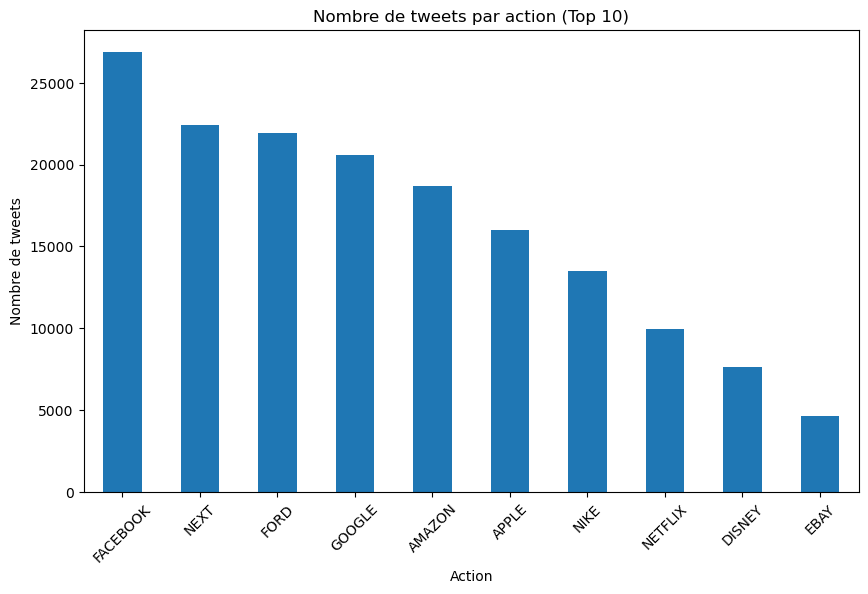

In [5]:
import matplotlib.pyplot as plt
tweets_per_action = data['STOCK'].value_counts()

# Sélectionner les 10 entreprises avec le plus de tweets
top_actions = tweets_per_action.head(10)

# Créer l'histogramme
plt.figure(figsize=(10, 6))
top_actions.plot(kind='bar')
plt.title('Nombre de tweets par action (Top 10)')
plt.xlabel('Action')
plt.ylabel('Nombre de tweets')
plt.xticks(rotation=45)
plt.show()

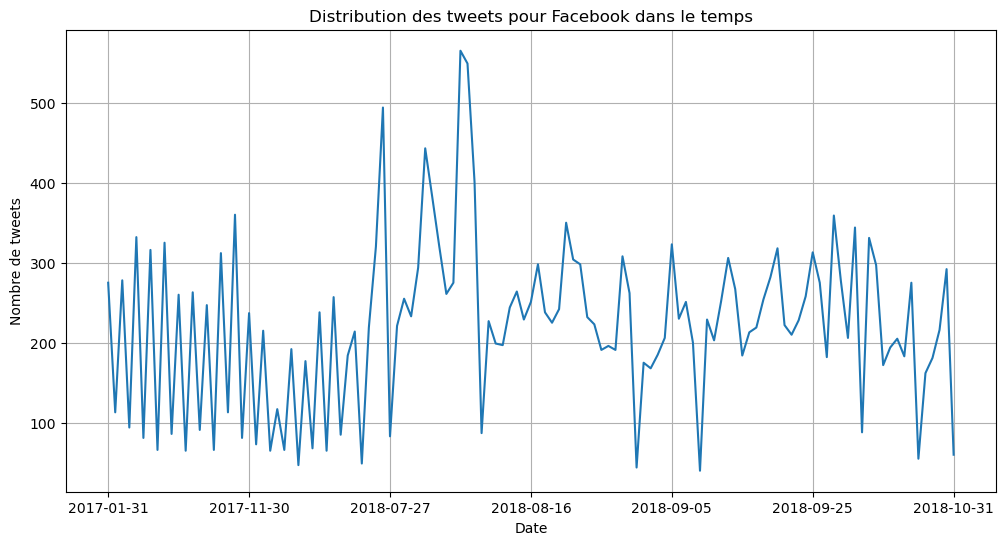

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrer les données sur 'FACEBOOK'
df_Facebook = data.loc[data['STOCK'] == 'FACEBOOK'].copy()

# Grouper par date et compter le nombre de tweets
tweets_per_date_facebook = df_Facebook.groupby('DATE').size()

# Trier l'index (facultatif si vous voulez les dates en ordre chronologique)
tweets_per_date_facebook = tweets_per_date_facebook.sort_index()

# Tracé
plt.figure(figsize=(12, 6))
tweets_per_date_facebook.plot()
plt.title("Distribution des tweets pour Facebook dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre de tweets")
plt.grid(True)
plt.show()


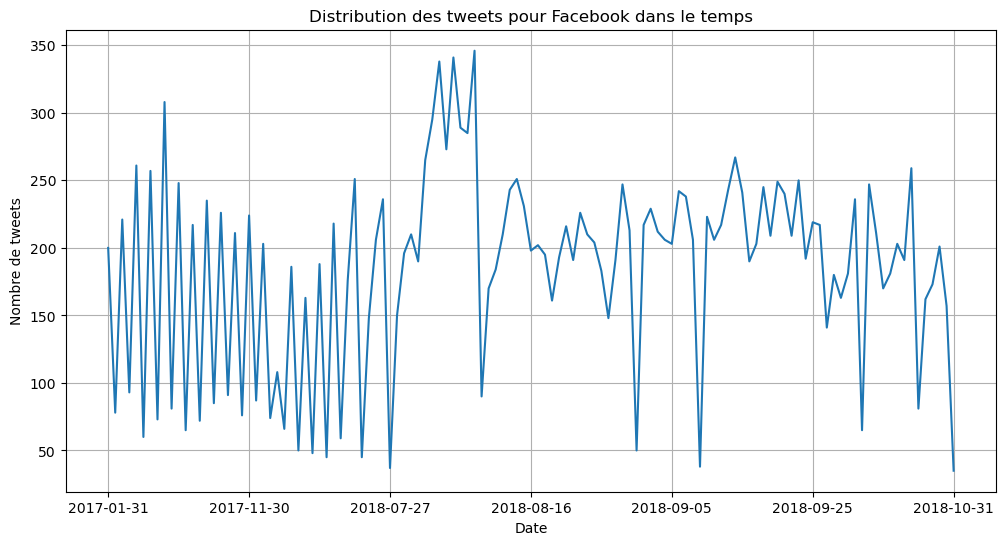

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrer les données sur 'FACEBOOK'
df_Next = data.loc[data['STOCK'] == 'NEXT'].copy()

# Grouper par date et compter le nombre de tweets
tweets_per_date_facebook = df_Facebook.groupby('DATE').size()

# Trier l'index (facultatif si vous voulez les dates en ordre chronologique)
tweets_per_date_facebook = tweets_per_date_facebook.sort_index()

# Tracé
plt.figure(figsize=(12, 6))
tweets_per_date_facebook.plot()
plt.title("Distribution des tweets pour Facebook dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre de tweets")
plt.grid(True)
plt.show()


In [9]:
pourcentage_tweets = sum(tweets_per_action[0:10])
print (pourcentage_tweets)

162288


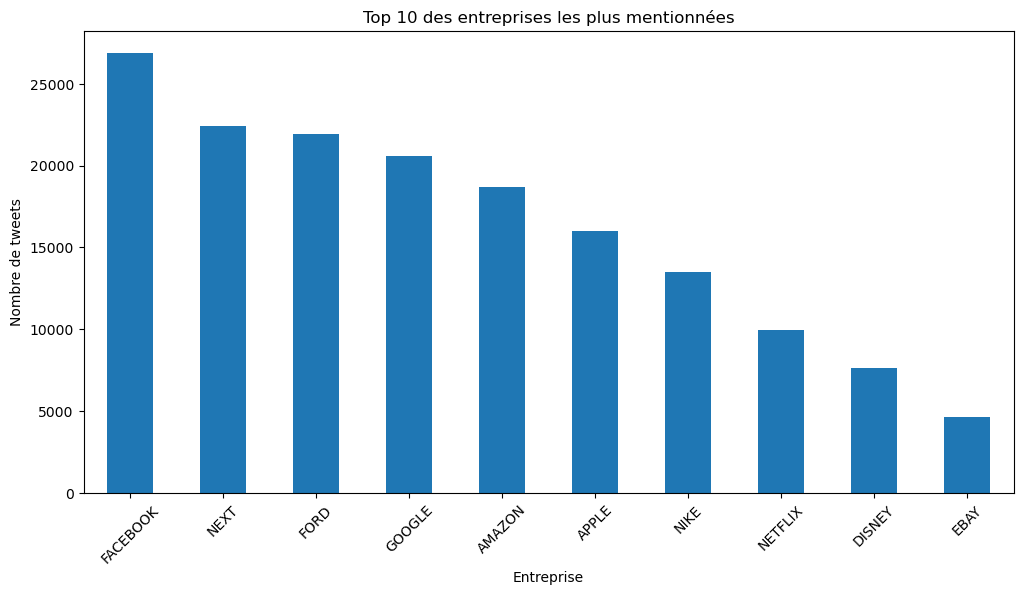

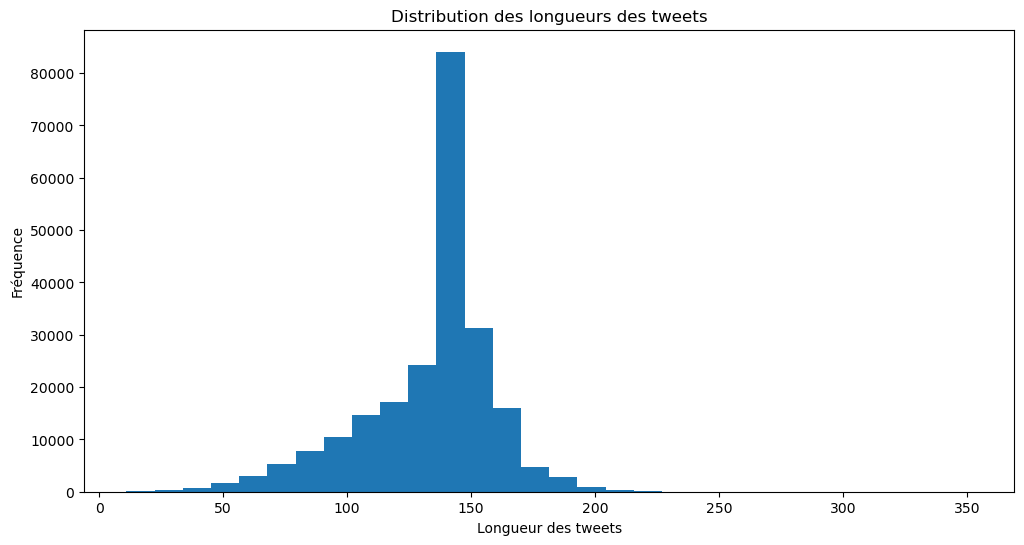

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Charger les données
file_path = 'data/sentiment_data_cleaned.csv'  # Remplacez par votre chemin
data = pd.read_csv(file_path)

# Étape 1 : Répartition des tweets par entreprise
tweets_per_action = data['STOCK'].value_counts()
plt.figure(figsize=(12, 6))
tweets_per_action.head(10).plot(kind='bar')
plt.title('Top 10 des entreprises les plus mentionnées')
plt.xlabel('Entreprise')
plt.ylabel('Nombre de tweets')
plt.xticks(rotation=45)
plt.show()

# Étape 3 : Distribution des longueurs des tweets
data['TWEET_LENGTH'] = data['TWEET'].apply(len)
plt.figure(figsize=(12, 6))
data['TWEET_LENGTH'].hist(bins=30)
plt.title('Distribution des longueurs des tweets')
plt.xlabel('Longueur des tweets')
plt.ylabel('Fréquence')
plt.grid()
plt.show()

